In [106]:
from hossam import *

import os

from pandas import DataFrame, concat
from matplotlib import pyplot as plt
import seaborn as sb
import numpy as np

from sklearn.model_selection import train_test_split

# 순서층을 구성하는 모델 객체 생성 기능
from tensorflow.keras.models import Sequential

# 모델 객체에 학습을 위한 층을 쌓는다.
from tensorflow.keras.layers import Dense, Input

# 옵티마이저
from tensorflow.keras.optimizers import SGD, RMSprop

# 활성화 함수
from tensorflow.keras.losses import mse

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# 성능평가함수
from tensorflow.keras.metrics import RootMeanSquaredError

# 로딩바
from tqdm.keras import TqdmCallback

In [107]:
origin = load_data("logical_xor")
origin

XOR 논리 게이트의 입력과 출력 데이터


,x1,x2,target
0,0,0,0
1,1,0,1
2,0,1,1
3,1,1,0


In [108]:
df = concat([origin] * 10, ignore_index=True)
df.describe()

,x1,x2,target
count,40.000,40.000,40.000
mean,0.500,0.500,0.500
std,0.506,0.506,0.506
min,0.000,0.000,0.000
25%,0.000,0.000,0.000
50%,0.500,0.500,0.500
75%,1.000,1.000,1.000
max,1.000,1.000,1.000


In [109]:
yname = "target"
x = df.drop(columns=[yname])
y = df[yname]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=52
)

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((30, 2), (10, 2), (30,), (10,))

In [110]:
rows, cols = x_train.shape
print(rows, cols)

30 2


In [111]:
# Sequential API를 사용하여 순차적으로 층을 쌓는 모델 객체 생성
model = Sequential()

# 입력층 정의: 각 샘플은 (cols,) 형태의 1차원 벡터임
# 예) cols=5이면 입력 데이터는 (None, 5) 구조가 됨 (None은 배치 크기)
model.add(Input(shape=(cols,)))

# Dense(완전연결층) 추가
# 출력 뉴런 1개 → 이진 분류 문제이므로 출력층 뉴런 수는 1개
model.add(Dense(4, activation="relu"))
model.add(Dense(1, activation="sigmoid"))

# 모델 학습 설정 (컴파일 단계)
model.compile(
    optimizer="SGD",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

# 모델 구조(층 구성, 파라미터 개수 등) 요약 출력
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

In [112]:
cwd = os.getcwd()
target_dir = os.path.join(cwd, "tensorflow_checkpoint")

if not os.path.exists(target_dir):
    os.mkdir(target_dir)

checkpoint_path = os.path.join(target_dir, "model04-cp-{epoch:04d}-ckpt.keras")
checkpoint_path

'/Users/jinwoo/Machine_Learning/LAB12-딥러닝/tensorflow_checkpoint/model04-cp-{epoch:04d}-ckpt.keras'

In [113]:
%%time
result = model.fit(
    x_train,                              # 학습 데이터 입력
    y_train,                              # 학습 데이터의 타겟값 (정답)
    epochs=500,                           # 전체 학습 데이터셋을 500회 반복하여 학습
    validation_data=(x_test, y_test),     # 검증 데이터 직접 지정
    verbose=0,                            # 학습 과정 출력 생략
    callbacks=[
        TqdmCallback(verbose=1),
        ModelCheckpoint(
            filepath=checkpoint_path,
            monitor="val_loss",
            verbose=0,
            save_best_only=True
        ),
        EarlyStopping(
            monitor="val_loss",
            patience=5,
            min_delta=0.0001
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=10,
            min_lr=0.0,
            verbose=1
        )
    ]
)
result

0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

CPU times: user 4.86 s, sys: 648 ms, total: 5.51 s
Wall time: 5.04 s


In [114]:
train_eval = model.evaluate(x_train, y_train, verbose=0, return_dict=True)
test_eval = model.evaluate(x_test, y_test, verbose=0, return_dict=True)

final_results = DataFrame([train_eval, test_eval])
final_results.insert(0, "Dataset", ["Train", "Test"])

final_results["loss_gap"] = None
final_results.loc[1, "loss_gap"] = (
    final_results.loc[1, "loss"] - final_results.loc[0, "loss"]
)

final_results

,Dataset,accuracy,loss,loss_gap
0,Train,0.467,0.677,None
1,Test,0.600,0.677,-0.000


In [119]:
history_df = DataFrame(data=result.history)
history_df["epoch"] = history_df.index + 1

history_df.head()

,accuracy,loss,val_accuracy,val_loss,learning_rate,epoch
0,0.733,0.758,0.800,0.762,0.010,1
1,0.733,0.757,0.800,0.761,0.010,2
2,0.733,0.757,0.800,0.760,0.010,3
3,0.733,0.756,0.800,0.760,0.010,4
4,0.733,0.755,0.800,0.759,0.010,5


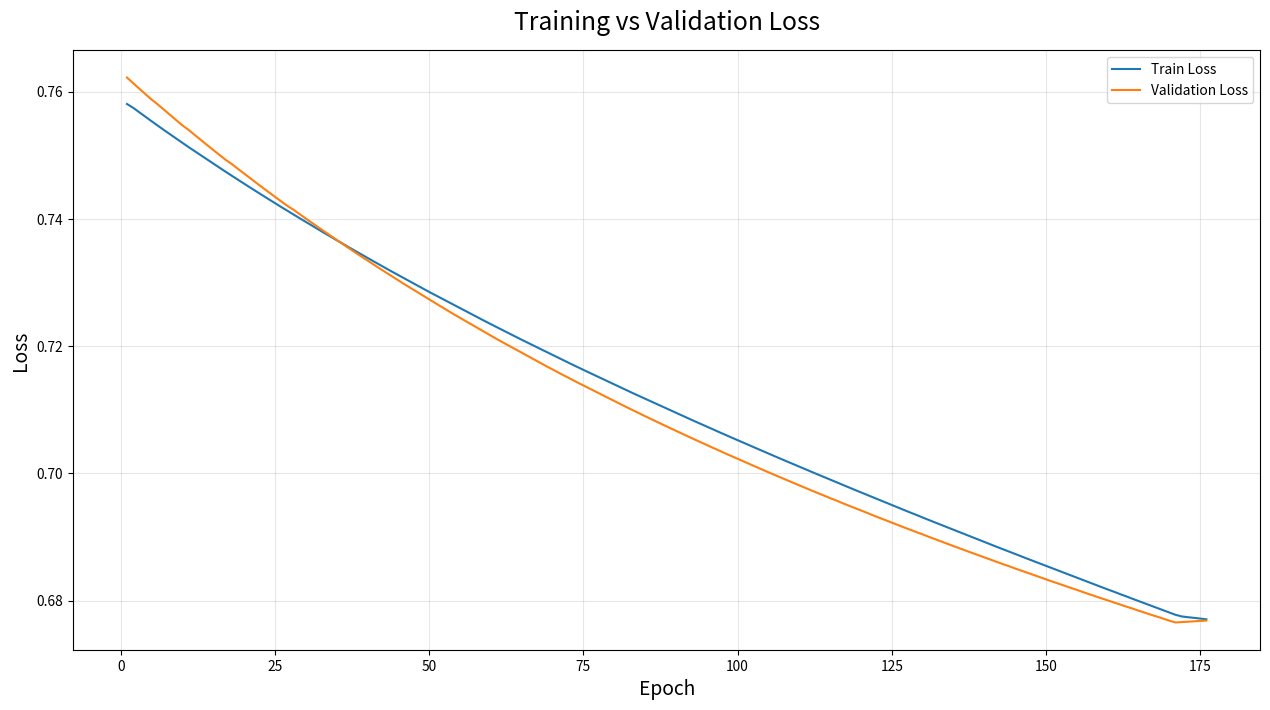

In [116]:
figsize = (1280 / 100, 720 / 100)
fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=100)

sb.lineplot(data=history_df, x="epoch", y="loss", ax=ax, label="Train Loss")

sb.lineplot(data=history_df, x="epoch", y="val_loss", ax=ax, label="Validation Loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training vs Validation Loss")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()

In [117]:
r = model.predict(x_test, verbose=0)
r

array([[0.46783176],
       [0.46783176],
       [0.46783176],
       [0.5628784 ],
       [0.46783176],
       [0.49157938],
       [0.49157938],
       [0.5628784 ],
       [0.5832098 ],
       [0.46783176]], dtype=float32)

In [118]:
y_pred = r.reshape(-1) > 0.5
y_df = DataFrame({"y_true": y_test, "y_pred": y_pred})
y_df["y_pred"] = y_df["y_pred"].astype(int)
y_df

,y_true,y_pred
36,0,0
8,0,0
0,0,0
35,0,1
24,0,0
2,1,0
18,1,0
19,0,1
21,1,1
4,0,0
